<a target="_blank" href="https://colab.research.google.com/github/nz-gravity/sgvb_psd/blob/main/docs/examples/lisa_example_v2.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# LISA Example V2

This example estimates the spectral density matrix of the three LISA TDI Michelson channels using the componentwise eigenbasis SGVB method introduced in `sgvb_psd` v2.0.0. The posterior estimate is compared with a Welch estimate for both the channel PSDs and pairwise coherences.

The noise-only `noise-4a` dataset is available from [Zenodo](https://zenodo.org/records/15698080). The `tdi.h5` download is approximately 505 MB.

In [ ]:
%pip install -q "setuptools<81" "sgvb_psd==2.0.0" "h5py>=3.15.1" scipy

In [ ]:
from pathlib import Path
from time import perf_counter
from urllib.request import urlretrieve

import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from scipy.signal.windows import kaiser

from sgvb_psd.postproc.plot_coherence import compute_coherence
from sgvb_psd.psd_estimator import PSDEstimator

## Download and load the data

In [ ]:
DATA_URL = "https://zenodo.org/records/15698080/files/tdi.h5?download=1"
DATA_PATH = Path("data/zenodo_15698080_tdi.h5")

DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
if not DATA_PATH.exists():
    print("Downloading the 505 MB LISA dataset...")
    urlretrieve(DATA_URL, DATA_PATH)

with h5py.File(DATA_PATH, "r") as f:
    time = f["t"][:]
    data = np.column_stack((f["X2"][:], f["Y2"][:], f["Z2"][:]))

dt = float(np.median(np.diff(time[:1000])))
fs = 1.0 / dt

## Block, taper, and calculate the Welch estimate

We use non-overlapping blocks of 16,384 samples, remove the mean of each block, and apply a Kaiser window with shape parameter 30. The normalized equivalent noise bandwidth `Nbw` is passed to the SGVB likelihood.

In [4]:
L = 2**14
FMIN, FMAX = 1e-4, 1e-1
window = kaiser(L, beta=30)

nchunks = len(data) // L
n_used = nchunks * L
chunks = data[:n_used].reshape(nchunks, L, 3)
chunks = chunks - chunks.mean(axis=1, keepdims=True)
window_energy = np.mean(window**2)
Nbw = L * np.sum(window**2) / np.sum(window) ** 2
windowed_data = (chunks * window[None, :, None]).reshape(n_used, 3)

def welch_spectral_matrix_xyz(x, y, z, L, dt, overlap=0.0):
    n_samples = len(x)
    step = int(L * (1 - overlap))
    w = kaiser(L, beta=30)
    U = np.mean(w**2)

    Sxx = Syy = Szz = 0
    Sxy = Syz = Szx = 0
    count = 0
    for start in range(0, n_samples - L + 1, step):
        xs = x[start:start + L] * w
        ys = y[start:start + L] * w
        zs = z[start:start + L] * w

        Xf = np.fft.rfft(xs)
        Yf = np.fft.rfft(ys)
        Zf = np.fft.rfft(zs)

        scale = 2.0 * dt / (L * U)
        Sxx += scale * (np.abs(Xf) ** 2)
        Syy += scale * (np.abs(Yf) ** 2)
        Szz += scale * (np.abs(Zf) ** 2)
        Sxy += scale * (Xf * np.conj(Yf))
        Syz += scale * (Yf * np.conj(Zf))
        Szx += scale * (Zf * np.conj(Xf))
        count += 1

    Sxx /= count
    Syy /= count
    Szz /= count
    Sxy /= count
    Syz /= count
    Szx /= count

    freq = np.fft.rfftfreq(L, d=dt)
    return freq, Sxx, Syy, Szz, Sxy, Syz, Szx


freq_welch, Sxx, Syy, Szz, Sxy, Syz, Szx = welch_spectral_matrix_xyz(
    data[:, 0], data[:, 1], data[:, 2], L=L, dt=dt, overlap=0.0
)

S_welch = np.zeros((len(freq_welch), 3, 3), dtype=complex)
S_welch[:, 0, 0], S_welch[:, 1, 1], S_welch[:, 2, 2] = Sxx, Syy, Szz
S_welch[:, 0, 1], S_welch[:, 1, 0] = Sxy, np.conj(Sxy)
S_welch[:, 1, 2], S_welch[:, 2, 1] = Syz, np.conj(Syz)
S_welch[:, 2, 0], S_welch[:, 0, 2] = Szx, np.conj(Szx)

print(f"{nchunks} blocks, Nbw={Nbw:.3f}")

384 blocks, Nbw=3.123

## Componentwise eigenbasis SGVB

The componentwise posterior approximation is selected with `use_eigenbasis=True` and `posterior_mode="factorized"`.

In [5]:
sgvb_start = perf_counter()
estimator = PSDEstimator(
    x=windowed_data,
    N_theta=250,
    nchunks=nchunks,
    fs=fs,
    ntrain_map=10000,
    n_elbo_maximisation_steps=600,
    fmin_for_analysis=FMIN,
    fmax_for_analysis=FMAX,
    degree_fluctuate=250,
    seed=0,
    Nbw=Nbw,
    use_eigenbasis=True,
    posterior_mode="factorized",
)
estimator.run(lr=0.0003)
sgvb_runtime = perf_counter() - sgvb_start
print(f"SGVB estimation time: {sgvb_runtime:.2f} s ({sgvb_runtime / 60:.2f} min)")

22:28:12|SGVB-PSD|INFO| Dividing data (6291456, 3) into (384, 16384, 3) chunks

22:28:12|SGVB-PSD|WARNING| nchunks must be a power of 2 for faster FFTs

22:28:12|SGVB-PSD|INFO| Reducing the number of frequencies to be analyzed from 8192 to 0.1...

22:28:12|SGVB-PSD|INFO| Final PSD will be of shape: 8183 x 3 x 3

22:28:13|SGVB-PSD|INFO| Loaded EigenbasisAnalysisData(x(t)=(6291456, 3), y(f)=(384, 8183, 3), Xmat_delta=(8183, 252), Xmat_theta=(8183, 252), Z=(8183, 3, 3, 3))

...

Block 2 step 5000 / 10000 : log posterior [1177367.12]


Block 2 step 10000 / 10000 : log posterior [1603696.25]


22:30:10|SGVB-PSD|INFO| Model trained in 117.00s

22:30:10|SGVB-PSD|INFO| Computing posterior PSDs

SGVB estimation time: 459.62 s (7.66 min)

## PSD and coherence comparison

The diagonal panels show the three channel PSDs. The lower-triangular panels show the magnitude coherence for each channel pair.

c:\Users\jliu812\AppData\Local\anaconda3\envs\mojito\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)


c:\Users\jliu812\AppData\Local\anaconda3\envs\mojito\Lib\site-packages\numpy\ma\core.py:2885: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


c:\Users\jliu812\AppData\Local\anaconda3\envs\mojito\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


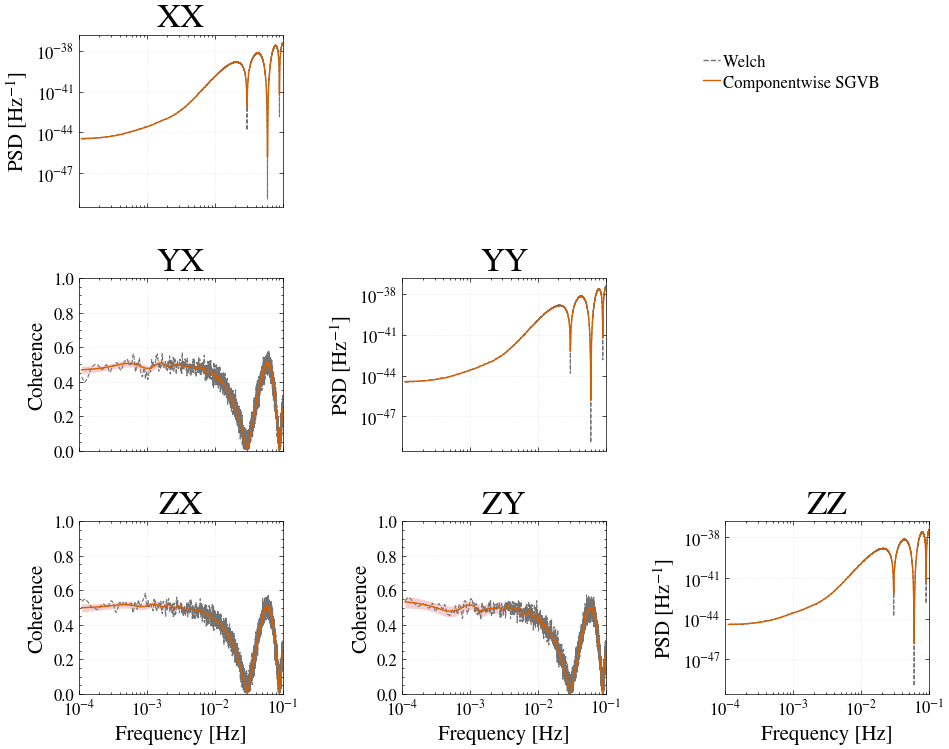

In [6]:
channels = ["X", "Y", "Z"]
sgvb_ci = estimator.uniform_ci * 2 / window_energy
welch_mask = (freq_welch >= FMIN) & (freq_welch <= FMAX)

sgvb_coherence = {}
for i, j in ((1, 0), (2, 0), (2, 1)):
    _, ci = compute_coherence(
        estimator.psd_all[:, :, i, i],
        estimator.psd_all[:, :, j, j],
        estimator.psd_all[:, :, i, j],
    )
    sgvb_coherence[i, j] = np.sqrt(np.clip(ci, 0, None))

fig, axes = plt.subplots(3, 3, figsize=(10, 8), sharex="col")
for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        if i < j:
            ax.axis("off")
            continue

        if i == j:
            ax.loglog(
                freq_welch[welch_mask],
                np.real(S_welch[welch_mask, i, i]),
                color="0.45", linestyle="--", linewidth=0.8,
            )
            ax.fill_between(
                estimator.freq, sgvb_ci[0, :, i, i], sgvb_ci[2, :, i, i],
                color="#F3C3C4", alpha=0.8, linewidth=0,
            )
            ax.loglog(
                estimator.freq, sgvb_ci[1, :, i, i],
                color="#D55E00", linewidth=1.0,
            )
            ax.set_ylabel(r"PSD [Hz$^{-1}$]")
        else:
            welch_coherence = np.abs(S_welch[:, i, j]) / np.sqrt(
                np.real(S_welch[:, i, i] * S_welch[:, j, j])
            )
            ci = sgvb_coherence[i, j]
            ax.semilogx(
                freq_welch[welch_mask], welch_coherence[welch_mask],
                color="0.45", linestyle="--", linewidth=0.8,
            )
            ax.fill_between(
                estimator.freq, ci[0], ci[2],
                color="#F3C3C4", alpha=0.8, linewidth=0,
            )
            ax.semilogx(estimator.freq, ci[1], color="#D55E00", linewidth=1.0)
            ax.set_ylim(0, 1)
            ax.set_ylabel("Coherence")

        ax.set_xlim(FMIN, FMAX)
        ax.grid(True, which="major", linestyle=":", alpha=0.35)
        ax.set_title(f"{channels[i]}{channels[j]}")
        if i == 2:
            ax.set_xlabel("Frequency [Hz]")

fig.legend(
    handles=[
        Line2D([0], [0], color="0.45", linestyle="--", label="Welch"),
        Line2D([0], [0], color="#D55E00", label="Componentwise SGVB"),
    ],
    loc="upper right", bbox_to_anchor=(0.92, 0.92), frameon=False,
)
fig.tight_layout()
plt.show()